Meta data propogated from the original catalogue selection cuts and choices:
OrderedDict([('QEVOL_N', 0.78), ('ZMAX_N', 0.6), ('ZMIN_N', 0.002), ('BRIGHT_N', 10.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('ZMAX_S', 0.6), ('ZMIN_S', 0.002), ('BRIGHT_S', 10.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 1.0), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313), ('EXTNAME', 'SLICES')])
redshift cuts: zbin_edges
----------
     0.002
      0.05
       0.1
       0.2
       0.3
       0.4
       0.5
       0.6
Replotting


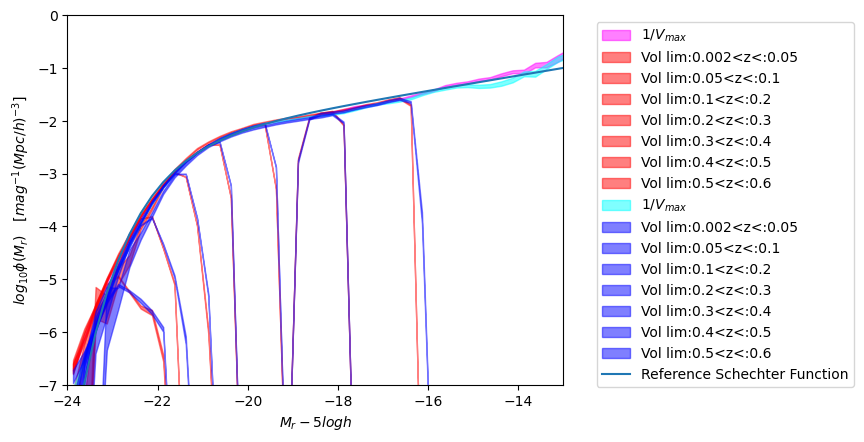

Replotting without errors but with boosts and shifts for incomplete bins


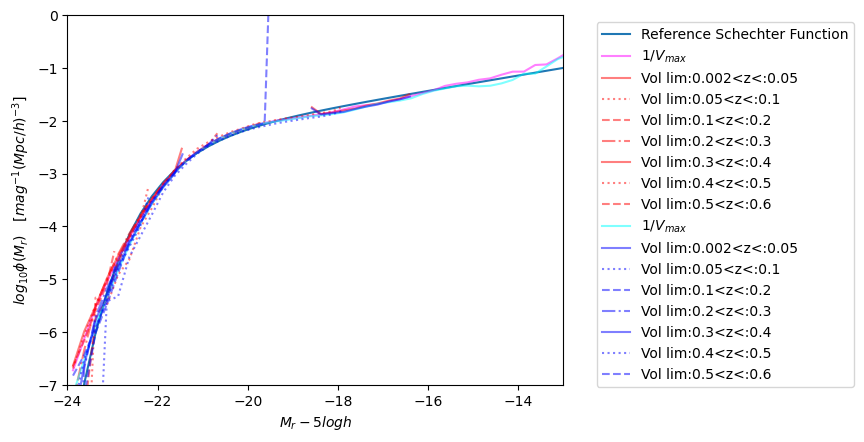

In [10]:
# Plot and manipulate the saved LFs from redshift slices
import matplotlib.pyplot as plt
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits

# Name of file containing LF estimates
LF_FILE='LF_Sept2025.fits'

# Specify regions to loop over
regions=('S','N')


# Read the redshift bins 
SLICES= Table.read(LF_FILE,hdu='SLICES')
zbin_edges=SLICES["zbin_edges"]
print("Meta data propogated from the original catalogue selection cuts and choices:")
print(SLICES.meta)
print('redshift cuts:',zbin_edges)

# Replot all the estimates
print('Replotting')

fig = plt.figure()         #defining so legend can be shifted  
ax = fig.add_subplot(111)

# Loop over regions
ireg = -1
col=('magenta','cyan') # colours for S and N overall 1/Vmax LFs
colz=('red','blue') # colours for S and N redshift slices
for reg in regions:
    ireg += 1
    #Replot the overall 1/Vmax LF estimate
    LF=Table.read(LF_FILE,hdu='LFVMAX'+reg)
    plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"],LF["log_phi_vmax_hi"],color=col[ireg],alpha=0.5,label="$1/V_{max}$")

    #loop over redshift bins
    for jzbin in range(0,zbin_edges.size-1):  
        zlabel=f"Vol lim:{zbin_edges[jzbin]}<z<:{zbin_edges[jzbin+1]}"
        LF=Table.read(LF_FILE,hdu='LFVLIM'+reg+str(jzbin))
        plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"],LF["log_phi_vmax_hi"],color=colz[ireg],alpha=0.5,label=zlabel)

# Reference Schechter function from Sam's draft paper Table 1
phi_star=10.0**(-2.13)
alpha=-1.36
mstar=-21.10
l_lstar= 10.0**(0.4*(-LF["magbins"]+mstar))
phi_sch= phi_star * l_lstar**(1.0+alpha) * np.exp(-l_lstar) *(np.log(10.0)/2.5)
log_phi_sch = np.log10(phi_sch)
plt.plot(LF["magbins"],log_phi_sch, label='Reference Schechter Function')
plt.xlabel('$M_r - 5 log h$')
plt.ylabel('$log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-24,-13])
plt.ylim([-7,0.0])
leg=plt.legend()

plt.draw() # Draw the figure so you can find the positon of the legend. 
# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 
# Change to location of the legend. 
xOffset = 0.6
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)
plt.show()

# Replot all the estimates without errors
print('Replotting without errors but with boosts and shifts for incomplete bins')
fig = plt.figure()         #defining so legend can be shifted  
ax = fig.add_subplot(111)

# Reference Schechter function from Sam's draft paper Table 1
plt.plot(LF["magbins"],log_phi_sch, label='Reference Schechter Function')


dmag=LF["magbins"][1]-LF["magbins"][0] # magnitude bin spacing
ireg = -1
style=('solid','dotted','dashed','dashdot','solid','dotted','dashed')
for reg in regions:
    ireg += 1
    # Replot the overall 1/Vmax LF estimate
    LF=Table.read(LF_FILE,hdu='LFVMAX'+reg)
    plt.plot(LF["magbins"],LF["log_phi_vmax"],color=col[ireg],alpha=0.5,label="$1/V_{max}$")
    # Read the faint and bright absolute magnitude bounds for this region
    BOUNDS=Table.read(LF_FILE,hdu='BOUNDS_'+reg)

    # loop over redshift bins
    for jzbin in range(0,zbin_edges.size-1):  
        zlabel=f"Vol lim:{zbin_edges[jzbin]}<z<:{zbin_edges[jzbin+1]}"
        LF=Table.read(LF_FILE,hdu='LFVLIM'+reg+str(jzbin))

        
        # Determine completeness of each magnitude bin from the bounding absolute magnitudes of this redshift slice

        #print('region',reg)
        #print('jzbin',jzbin)
        #print('bounds:',bright_bound[ireg,jzbin],faint_bound[ireg,jzbin])
        maghi=np.clip(LF["magbins"]+0.5*dmag,-100.0,BOUNDS["faint"][jzbin]) # hi-edge of occupied portion of the bin
        maglo=np.clip(LF["magbins"]-0.5*dmag,BOUNDS["bright"][jzbin],100.0) # lo-edge of occupied portion of the bin
        compl=np.clip((maghi-maglo)/dmag,0.0,1.0) #fraction of the bin occupied
      
        magbins_shifted=np.copy(LF["magbins"])
        notcomplete=(compl<1.0) & (compl>0.0)
        magbins_shifted[notcomplete]=0.5*(maghi[notcomplete]+maglo[notcomplete]) # just shift the partially complete bins
       
        magshifts=(LF["magbins"]-magbins_shifted)/dmag
        # mask empty bins and don't plot them  
        mask=compl>0.0
        #print('magbinshifts',magshifts[mask])   
        #print('boosts:',-np.log10(compl[mask]))
        plt.plot(magbins_shifted[mask],LF["log_phi_vmax"][mask]-np.log10(compl[mask]),color=colz[ireg],alpha=0.5,label=zlabel,linestyle=style[jzbin])
       

plt.xlabel('$M_r - 5 log h$')
plt.ylabel('$log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-24,-13])
plt.ylim([-7,0.0])
leg=plt.legend()

plt.draw() # Draw the figure so you can find the positon of the legend. 
# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 
# Change to location of the legend. 
xOffset = 0.6
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)
plt.show()